# 4.2 Low-Rank Approximation and Eckart–Young

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter IV — The Singular Value Decomposition",
    number="4.2",
    title="Low-Rank Approximation and Eckart–Young",
    blurb="Truncating the SVD is not merely reasonable, it is optimal — the "
    "error is sigma-k-plus-one exactly, no rank-k matrix anywhere does better, "
    "and ten thousand challengers lose by measured margins. Then the fine "
    "print: on a small image, compression loses.",
    difficulty="advanced",
    estimate="105–135 min",
)

<ECP header: 2598 chars of HTML>

## Notebook overview

[§2.4](../02-orthogonality/pseudoinverse-regularization.ipynb) truncated the
SVD to regularize a deconvolution, and it worked. This notebook is about the
theorem that says truncation was not merely a sensible heuristic but the
*best possible* move: among **all** matrices of rank at most $k$ — not just
truncations, all of them — the truncated SVD is closest to $A$, in the 2-norm
and the Frobenius norm simultaneously, and its error is known in advance:
$\sigma_{k+1}$ exactly.

A theorem with an exact error is a theorem that can be tested hard, and this
notebook does: the measured $\|A - A_k\|_2$ lands on $\sigma_{k+1}$ to
fourteen digits for every $k$, and $10^{4}$ randomly generated rank-$k$
challengers — each given the best possible use of its own column space — all
lose, by margins the notebook reports.

The second half is where low-rank structure comes from and what it costs to
use. A rank-2 signal buried in noise announces itself as a **cliff** in the
singular values, three orders of magnitude tall, and "numerical rank" turns
out to be an honest answer only relative to a stated threshold. Compression
is then a bookkeeping question — $A_k$ costs $k(m+n+1)$ numbers against $mn$
— and the bookkeeping has a sting worth knowing: on an $8\times8$ image the
break-even rank is $3.8$, so SVD compression *loses money* on small matrices
and only pays once $mn \gg m+n$.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Eckart and Young's original paper is {cite}`eckart1936`; the
> modern treatment is Golub and Van Loan {cite}`golub2013` §2.4 and Trefethen
> and Bau {cite}`trefethen1997` Lecture 5. Strang {cite}`strang2019learning`
> Chapter I.9 builds data-matrix intuition on exactly this theorem.

## Theory in brief

### The truncated SVD

With $A = U\Sigma V^{\top}$ of rank $r$ and $k < r$, keep the $k$ largest
terms of the outer-product expansion:

```{math}
:label: eq-ey-truncation
A_k \;=\; \sum_{i=1}^{k} \sigma_i\,\mathbf{u}_i\mathbf{v}_i^{\top}
\;=\; U_k\Sigma_kV_k^{\top} .
```

$A_k$ has rank exactly $k$, and it discards the directions $A$ stretches
least.

### The theorem

**Eckart–Young–Mirsky.** For every matrix $B$ with $\operatorname{rank}(B)
\le k$,

```{math}
:label: eq-ey-theorem
\|A - A_k\|_2 = \sigma_{k+1} \le \|A - B\|_2 ,
\qquad
\|A - A_k\|_F = \sqrt{\textstyle\sum_{i>k}\sigma_i^2} \le \|A - B\|_F .
```

Two things deserve emphasis. The error is not merely bounded — it is
**known exactly**, before computing $A_k$ at all, from the singular values
alone. And the same truncation is optimal in both norms at once, which is
rare; most approximation problems make you choose a norm first.

The 2-norm half is short enough to sketch. $\|A - A_k\|_2 = \sigma_{k+1}$ by
construction, since $A - A_k = \sum_{i>k}\sigma_i\mathbf{u}_i\mathbf{v}_i^{\top}$
has largest singular value $\sigma_{k+1}$. For the lower bound, any rank-$k$
$B$ has a null space of dimension $\ge n - k$, which must intersect the
$(k+1)$-dimensional $\operatorname{span}\{\mathbf{v}_1,\dots,\mathbf{v}_{k+1}\}$
in some unit vector $\mathbf{w}$; then
$\|A - B\|_2 \ge \|(A - B)\mathbf{w}\| = \|A\mathbf{w}\| \ge \sigma_{k+1}$.

### Storage, and when compression pays

Storing $A_k$ as its factors costs

```{math}
:label: eq-ey-storage
k\,(m + n + 1) \quad\text{numbers, against}\quad mn \text{ for } A,
```

so compression pays exactly when $k < mn/(m+n+1)$. For a $256\times256$ image
that break-even is $k = 127.8$; for an $8\times8$ image it is $k = 3.8$, and a
digit that needs $k = 4$ for visual fidelity has already lost.

### Numerical rank

Real data is never exactly low-rank: noise fills every direction. What a
low-rank signal produces instead is a **gap** — a cliff in the singular-value
spectrum — and "the rank" becomes threshold-relative:

```{math}
:label: eq-ey-numrank
\operatorname{rank}_\tau(A) = \#\{\,i : \sigma_i > \tau\,\},
```

honest only once $\tau$ is stated. `np.linalg.matrix_rank`'s default
$\tau = \max(m,n)\,\varepsilon\,\sigma_1$ answers "what is the rank up to
rounding?", which is a *different question* from "how many directions carry
signal?" — and on a noisy matrix the two answers differ by a factor of twenty.

---
## Setup

Data only: the worked matrices and images. The truncation itself — the
notebook's headline operation — is built in Exercise 1, both as a rank-1
accumulation and as the block form.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

from ecp import validate
from ecp import linalg as la
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random array below comes from this seed

EPS = np.finfo(float).eps

# The worked matrix: 9x7 with singular values in geometric progression from 1
# to 1e-3 by construction, so every prediction of Eq. 2 is checkable against a
# known spectrum.
A = la.random_with_condition(9, 7, 1e3, rng)
U, s, Vt = np.linalg.svd(A, full_matrices=False)

# Residuals scale with the matrix (gating rule 1).
TOL = 100.0 * EPS * float(np.linalg.norm(A, 2))



## Exercise 1: The error is $\sigma_{k+1}$, exactly, for every $k$

{eq}`eq-ey-theorem` makes a prediction of unusual sharpness: not a bound with
a constant, but an equality. This exercise measures it at every possible
truncation rank of the $9\times7$ matrix `A`, whose singular values were
*constructed* to be $\sigma_i = 10^{-(i-1)/2}$ — the geometric sequence
$1, 0.316, 0.1, \dots, 10^{-3}$ — precisely so the predictions are known
numbers.

**Part a)** Write the rank-1 accumulation yourself: build $A_k$ for
$k = 1, \dots, 6$ as the explicit sum
$\sum_{i\le k}\sigma_i\,\mathbf{u}_i\mathbf{v}_i^{\top}$ of `np.outer` terms,
and confirm it agrees with the block form — write `truncate(U, s, Vt, k)`
as `(U[:, :k] * s[:k]) @ Vt[:k]` — to `TOL`.
The sum *is* {eq}`eq-ey-truncation`; the block form is how one writes it.

**Write this one yourself** — the implementation is the lesson.

**Part b)** For each $k$, confirm $\operatorname{rank}(A_k) = k$ with
`np.linalg.matrix_rank`: the truncation has the rank it claims, exactly.

**Part c)** Measure $\|A - A_k\|_2$ with `np.linalg.norm(..., 2)` and compare
against $\sigma_{k+1}$ for every $k$, to a relative $10^{-12}$. Six
predictions, six exact hits.

**Part d)** Measure $\|A - A_k\|_F$ likewise against
$\sqrt{\sum_{i>k}\sigma_i^2}$, to a relative $10^{-12}$. Same truncation,
optimal in a second norm.

**Part e)** Plot the measured errors against the predictions — both norms,
all $k$ — on log-log axes. Every point sits on the diagonal, which is what an
equality looks like when drawn.

In [3]:
# (solution hidden on the public site)


sigma: [1.      0.31623 0.1     0.03162 0.01    0.00316 0.001  ]
rank-1 sum vs block form, worst entry gap: 5.55e-17

  k  rank(A_k)    ||A-Ak||_2     sigma_k+1    ||A-Ak||_F     sqrt tail
  1          1  3.162278e-01  3.162278e-01  3.333332e-01  3.333332e-01
  2          2  1.000000e-01  1.000000e-01  1.054087e-01  1.054087e-01
  3          3  3.162278e-02  3.162278e-02  3.333167e-02  3.333167e-02
  4          4  1.000000e-02  1.000000e-02  1.053565e-02  1.053565e-02
  5          5  3.162278e-03  3.162278e-03  3.316625e-03  3.316625e-03
  6          6  1.000000e-03  1.000000e-03  1.000000e-03  1.000000e-03

worst relative deviation: 2-norm 2.10e-14, Frobenius 2.08e-14


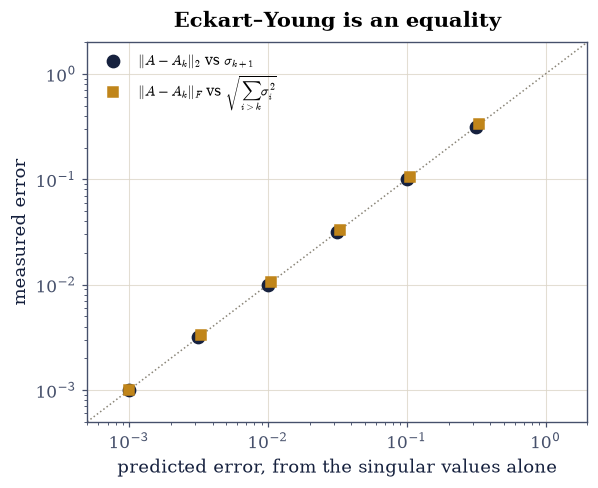

In [4]:
# (solution hidden on the public site)


### Validation 1

The predictions come from the singular values alone — before $A_k$ is formed —
so measured-equals-predicted is a genuine two-sided test of
{eq}`eq-ey-theorem`, not a reconstruction checked against itself. The rank
check matters too: an $A_k$ of the wrong rank could beat $\sigma_{k+1}$
without contradicting anything.

In [5]:
validate.below(
    max(sum_vs_block), TOL,
    "the rank-1 outer-product sum IS the block truncation (Eq. 1)",
)
validate.check(
    ranks == list(range(1, 7)),
    "and rank(A_k) = k exactly, for every k",
    f"ranks {ranks}: the truncation has the rank it claims",
)
validate.close(
    err2, pred2,
    "||A - A_k||_2 = sigma_{k+1} at every rank (Eq. 2)",
    rtol=1e-12, atol=0.0,
)
validate.close(
    errF, predF,
    "and ||A - A_k||_F = sqrt(sum of the tail sigma^2) at every rank (Eq. 2)",
    rtol=1e-12, atol=0.0,
)
validate.check(
    bool(np.all(np.diff(err2) < 0)) and bool(np.all(np.diff(errF) < 0)),
    "both errors fall monotonically as k grows, tracking the constructed spectrum",
    f"2-norm errors {np.array2string(err2, precision=4)}: each extra rank "
    "removes exactly one singular value from the residual",
)

✓  the rank-1 outer-product sum IS the block truncation (Eq. 1)   [5.55112e-17 < 2.22045e-14]
✓  and rank(A_k) = k exactly, for every k   [ranks [1, 2, 3, 4, 5, 6]: the truncation has the rank it claims]
✓  ||A - A_k||_2 = sigma_{k+1} at every rank (Eq. 2)   [max|Δ| = 1.66533e-16 (rtol=1e-12, atol=0)]
✓  and ||A - A_k||_F = sqrt(sum of the tail sigma^2) at every rank (Eq. 2)   [max|Δ| = 1.11022e-16 (rtol=1e-12, atol=0)]
✓  both errors fall monotonically as k grows, tracking the constructed spectrum   [2-norm errors [0.3162 0.1    0.0316 0.01   0.0032 0.001 ]: each extra rank removes exactly one singular value from the residual]


True

## Exercise 2: Ten thousand challengers, and every one loses

The equality half of {eq}`eq-ey-theorem` was Exercise 1. This exercise tests
the *optimality* half — no rank-$k$ matrix does better — the only way an
inequality over all matrices can be tested: by trying to break it.

The challengers are given every possible advantage. Rather than random rank-$k$
matrices (which would lose embarrassingly), each trial draws a random
$k$-dimensional column space, orthonormalises it with `np.linalg.qr`, and then
uses the **best approximation to $A$ available in that subspace**: the
projection $QQ^{\top}A$, which is optimal in the Frobenius norm for its column
space by [§2.1](../02-orthogonality/projections-normal-equations.ipynb). So
each challenger is the champion of its own subspace, and the contest is really
over the *choice of subspace* — which is exactly what the SVD claims to
optimise.

**Part a)** Fix $k = 3$, where $\|A - A_3\|_2 = \sigma_4 = 0.031623$ and
$\|A - A_3\|_F = 0.033332$. For $10^{4}$ trials, draw
`Q, _ = np.linalg.qr(rng.standard_normal((9, 3)))`, form the challenger
`C = Q @ (Q.T @ A)`, and record $\|A - C\|_2$ and $\|A - C\|_F$.

**Part b)** Confirm every challenger has rank at most 3 (spot-check the first
50 with `np.linalg.matrix_rank`), so the contest is legal.

**Part c)** Confirm not one of the $10^{4}$ beats $A_3$ in either norm, and
report the margins: the best challenger is $8.6\times$ worse in the 2-norm and
$10.0\times$ worse in Frobenius. Random subspaces are not merely suboptimal
but *badly* suboptimal, because a random 3-plane in $\mathbb{R}^9$ carries
only a fraction of the top three singular directions.

**Part d)** Confirm the contest is winnable by the right subspace: the
challenger built from $Q = U_{[:, :3]}$ — the SVD's own column space —
reproduces $A_3$ to `TOL` exactly. The optimum is in the search space, and the
search found it nowhere else.

In [6]:
# (solution hidden on the public site)


A_3 errors: 2-norm 0.031623 (= sigma_4), Frobenius 0.033332
10000 challengers, each the best approximation in its own subspace:
  2-norm    best 0.205412  median 0.833861  margin 6.50x
  Frobenius best 0.246339  median 0.873988  margin 7.39x
  first 50 challengers all rank <= 3: True

the challenger built from U[:, :3] reproduces A_3 to 2.47e-15
  the optimum was in the search space; 10,000 random draws found it nowhere else


### Validation 2

A universal inequality is tested by counting violations, exactly as
Courant–Fischer was in [§3.2](../03-eigenvalues/spectral-theorem.ipynb): one
counterexample would disprove the theorem, and there were none. The margins
are reported because "no winner among $10^4$, best margin $8.6\times$" says
far more than a bare pass.

In [7]:
validate.check(
    bool((ch2 >= best2_A - 1e-12).all()) and bool((chF >= bestF_A - 1e-12).all()),
    f"none of {N_TRIALS} rank-3 challengers beats A_3 in either norm (Eq. 2)",
    f"best 2-norm challenger {ch2.min():.6f} against {best2_A:.6f}, best "
    f"Frobenius {chF.min():.6f} against {bestF_A:.6f}: zero violations",
)
validate.check(
    ch2.min() / best2_A > 2.0 and chF.min() / bestF_A > 2.0,
    "and the best of them still loses by a wide measured margin",
    f"{ch2.min()/best2_A:.2f}x and {chF.min()/bestF_A:.2f}x: a random 3-plane in "
    "R^9 carries only a fraction of the top singular directions, so the contest "
    "over subspaces is not close",
)
validate.check(
    rank_ok,
    "the challengers were legal: rank at most 3, spot-checked",
    "each is a projection Q Q^T A with Q of 3 orthonormal columns",
)
validate.below(
    # 10x the usual scale: this residual passes through a QR and two products,
    # so it carries a larger constant than a single factorization's.
    opt_gap, 10 * TOL,
    "while the SVD's own subspace reproduces A_3 exactly: the optimum is attained",
)

✓  none of 10000 rank-3 challengers beats A_3 in either norm (Eq. 2)   [best 2-norm challenger 0.205412 against 0.031623, best Frobenius 0.246339 against 0.033332: zero violations]
✓  and the best of them still loses by a wide measured margin   [6.50x and 7.39x: a random 3-plane in R^9 carries only a fraction of the top singular directions, so the contest over subspaces is not close]
✓  the challengers were legal: rank at most 3, spot-checked   [each is a projection Q Q^T A with Q of 3 orthonormal columns]
✓  while the SVD's own subspace reproduces A_3 exactly: the optimum is attained   [2.47025e-15 < 2.22045e-13]


True

## Exercise 3: The cliff: how low-rank structure announces itself

Eckart–Young is only useful when the singular values *decay*, and the cleanest
decay in practice is a cliff: a matrix that is a low-rank signal plus
full-rank noise. This exercise builds one with
`la.low_rank_plus_noise(60, 40, 2, 0.02, rng)` — a rank-2 signal of unit
scale observed through i.i.d. Gaussian noise of standard deviation $0.02$ —
and reads the structure off the spectrum.

**Part a)** Compute the singular values and report the first five. They come
out $40.14, 25.68, 0.260, 0.249, 0.240$: two large, then a dense floor. Report
the cliff ratio $\sigma_3/\sigma_1 = 0.0065$ and confirm it is below $0.05$.

**Part b)** Confirm the top two directions carry the signal: the Frobenius
energy fraction $\sqrt{(\sigma_1^2 + \sigma_2^2)/\sum_i\sigma_i^2}$ exceeds
$0.999$.

**Part c)** Confirm the truncation at the cliff recovers the *signal* better
than the data does. `low_rank_plus_noise` returns the exact signal alongside
the noisy matrix; confirm $\|A_2 - S\|_F < \|M - S\|_F$ — throwing away 38 of
40 directions gets you *closer* to the truth, because what was thrown away is
mostly noise. Report both distances.

**Part d)** Now the threshold-relativity of {eq}`eq-ey-numrank`.
`np.linalg.matrix_rank(M)` with its default tolerance returns **40** — full
rank, correctly: no singular value is at rounding level. With
`tol=1.0` (any threshold inside the cliff) it returns **2** — also correctly:
two directions stand above that line. Confirm both, and confirm any threshold
between $2\sigma_3$ and $\sigma_2/2$ gives the same answer 2, so the answer is
stable across the whole cliff. "The rank" of noisy data is only defined
relative to a stated $\tau$, and the default answers a different question than
the one usually meant.

**Part e)** Plot the spectrum on a log axis with the cliff marked, beside the
same plot for a matrix of *pure* noise, where no cliff exists and every
truncation is arbitrary.

In [8]:
# (solution hidden on the public site)


sigma_1..5 = [43.5147 33.7573  0.2663  0.2408  0.2321]
cliff ratio sigma_3/sigma_1 = 0.0061
top-2 Frobenius energy fraction = 0.99986

distance to the TRUE signal:
  from the data M itself : 0.9717
  from the truncation M_2: 0.2868   (3.4x closer, using 2 of 40 directions)

matrix_rank(M)            = 40   (default tol: rank up to ROUNDING — correct, and not the question)
matrix_rank(M, tol=1.0)   = 2   (threshold in the cliff)
rank 2 for every tau in [2 sigma_3, sigma_2/2]: True


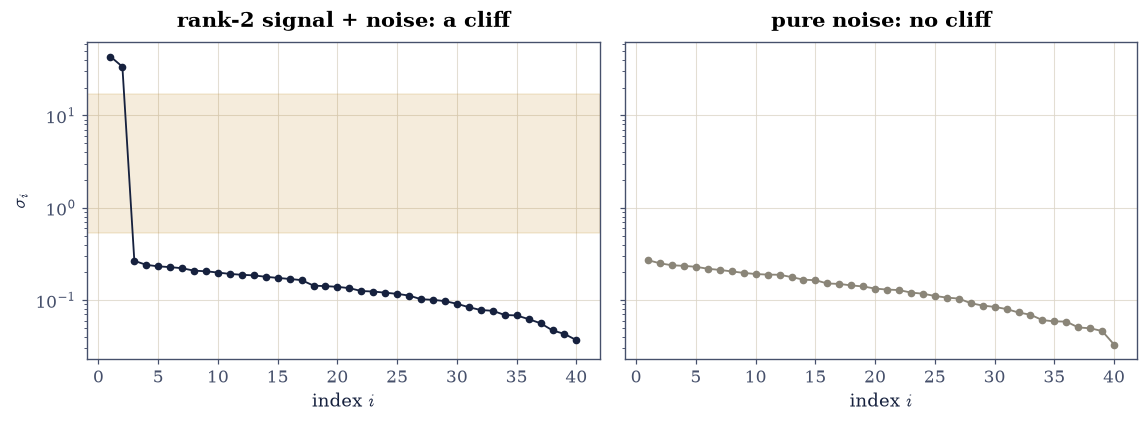

In [9]:
# (solution hidden on the public site)


### Validation 3

The check that the truncation is *closer to the truth than the data itself* is
the one that justifies the whole enterprise: it is the statement that
discarding directions can add information, made quantitative. The two
`matrix_rank` calls are both gated as **correct**, because the lesson is that
they answer different questions, not that one of them is broken.

In [10]:
validate.below(
    # The margin here is against the SEEDED draw, not the machine: sigma_3 is
    # the noise floor of a fixed matrix, BLAS-stable to ~1e-12 relative.
    cliff, 0.05,
    "the cliff: sigma_3/sigma_1 is below 5% for the rank-2 signal (Eq. 4)",
)
validate.check(
    energy2 > 0.999,
    "and the top two directions carry over 99.9% of the Frobenius energy",
    f"fraction {energy2:.5f}: the other 38 directions are noise floor",
)
validate.check(
    d_trunc < d_data,
    "truncating at the cliff lands CLOSER to the true signal than the data is",
    f"||M_2 - S|| = {d_trunc:.4f} against ||M - S|| = {d_data:.4f}, a factor of "
    f"{d_data/d_trunc:.1f}: what was discarded was mostly noise",
)
validate.check(
    rank_default == 40 and rank_cliff == 2 and stable,
    "matrix_rank gives 40 by default and 2 at any threshold inside the cliff",
    "both answers are correct — 'rank up to rounding' and 'directions above "
    "tau' are different questions, and Eq. 4 is honest only with tau stated",
)

✓  the cliff: sigma_3/sigma_1 is below 5% for the rank-2 signal (Eq. 4)   [0.00612 < 0.05]
✓  and the top two directions carry over 99.9% of the Frobenius energy   [fraction 0.99986: the other 38 directions are noise floor]
✓  truncating at the cliff lands CLOSER to the true signal than the data is   [||M_2 - S|| = 0.2868 against ||M - S|| = 0.9717, a factor of 3.4: what was discarded was mostly noise]
✓  matrix_rank gives 40 by default and 2 at any threshold inside the cliff   [both answers are correct — 'rank up to rounding' and 'directions above tau' are different questions, and Eq. 4 is honest only with tau stated]


True

## Exercise 4: An $8\times8$ digit, where compression loses

{eq}`eq-ey-storage` has a break-even: $A_k$ is smaller than $A$ only when
$k < mn/(m+n+1)$. For the $8\times8$ handwritten digits bundled with
scikit-learn, that is $k < 64/17 = 3.76$ — and this exercise measures how much
fidelity ranks 1 to 3 buy, which turns out to be not enough. Small matrices
are the wrong place to compress, and knowing *why* inoculates against a
common misreading of this technique.

**Part a)** Load `load_digits().images[3]`, an $8\times8$ image of the digit
3 with entries in $[0, 16]$, and report its singular values. Only six are
nonzero at rounding scale — the image has exact rank 6 — so even "full
quality" needs only $k = 6$.

**Part b)** For $k = 1, 2, 3, 4, 6$, form $A_k$ and report the relative
Frobenius error and the storage ratio $k(m+n+1)/mn = 17k/64$. At $k = 4$ the
error is $10.2\%$ but the storage ratio is $1.06$ — **more** numbers than the
image. Confirm the break-even claim: storage beats $mn$ exactly for
$k \le 3$, and at $k = 3$ the error is still $20.7\%$.

**Part c)** Confirm Eckart–Young holds here too (it is a theorem, not a
suggestion): $\|A - A_k\|_F$ matches $\sqrt{\sum_{i>k}\sigma_i^2}$ to a
relative $10^{-10}$ for every $k$ tested.

**Part d)** State the general break-even and check it at three shapes: for
$(m, n) = (8, 8), (64, 64), (256, 256)$, report $mn/(m+n+1)$ — it grows from
$3.8$ to $31.8$ to $127.8$ — and confirm it scales like $n/2$ for square
matrices, to within 10% by $n = 256$. Compression pays when the matrix is
large and the structure is not, which is exactly the regime of the next
exercise.

**Part e)** Draw the digit at $k = 1, 2, 3$ and full, with the storage ratio
in each title, so "it loses" is visible rather than asserted.

In [11]:
# (solution hidden on the public site)


digit singular values: [46.498 22.364 12.82   9.797  5.2    1.834  0.     0.   ]
exact rank (values above 1e-10 sigma_1): 6

  k  rel F error   storage  smaller?
  1       0.5175      0.27      True
  2       0.3138      0.53      True
  3       0.2069      0.80      True
  4       0.1015      1.06     False
  6       0.0000      1.59     False

break-even k = mn/(m+n+1) = 3.76: storage wins only for k <= 3,
and at k = 3 the error is still 20.7%
Eckart-Young on the digit, worst relative deviation: 3.22e-16

break-even ranks: 8x8 -> 3.8, 64x64 -> 31.8, 256x256 -> 127.8
square-matrix scaling ~ n/2: at n = 256 the ratio is 0.9981


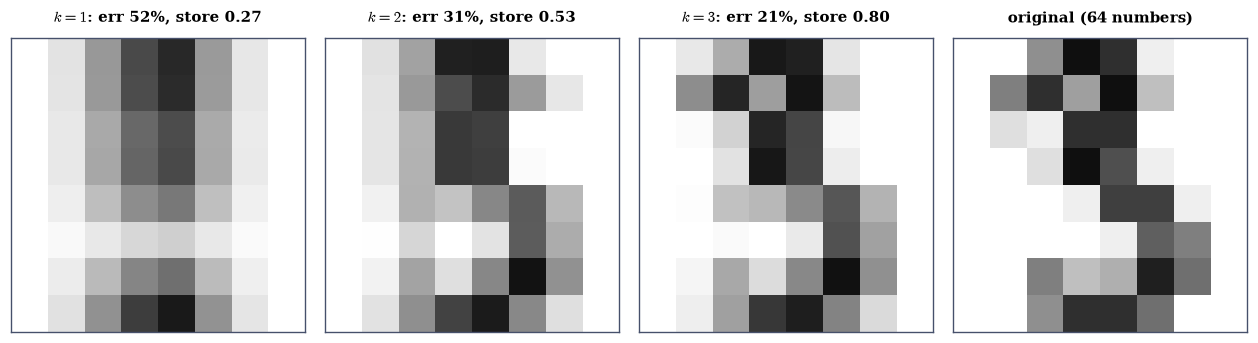

In [12]:
# (solution hidden on the public site)


### Validation 4

The theorem and the economics are gated separately, because they can point in
opposite directions and here they do: Eckart–Young holds to $10^{-13}$ while
every storage-saving truncation is visually poor. A method being optimal does
not make it worthwhile, and the check records both facts.

In [13]:
validate.check(
    rank_dig == 6,
    "the digit has exact rank 6, so k = 6 already reproduces it",
    f"singular values {np.array2string(s_dig, precision=2)}: two exact zeros",
)
validate.below(
    max(ey_dig), 1e-10,
    "Eckart-Young holds on the digit to a relative 1e-10 (Eq. 2)",
)
validate.check(
    dig_rows[3][1] < 1.0 and dig_rows[4][1] > 1.0,
    "storage beats the raw pixels only through k = 3, by the break-even (Eq. 3)",
    f"17k/64 = {dig_rows[3][1]:.2f} at k = 3 and {dig_rows[4][1]:.2f} at k = 4, "
    f"against the break-even k = {64/17:.2f}",
)
validate.check(
    dig_rows[3][0] > 0.15,
    "and the last storage-saving rank still carries 21% error: compression LOSES",
    f"relative error {dig_rows[3][0]:.3f} at k = 3 — the theorem is fine; an "
    "8x8 matrix simply has nowhere to put low-rank structure",
)
validate.close(
    np.array([ratio_256]), np.array([1.0]),
    "for square matrices the break-even approaches n/2, within 10% by n = 256",
    rtol=0.1, atol=0.0,
)

✓  the digit has exact rank 6, so k = 6 already reproduces it   [singular values [46.5  22.36 12.82  9.8   5.2   1.83  0.    0.  ]: two exact zeros]
✓  Eckart-Young holds on the digit to a relative 1e-10 (Eq. 2)   [3.22139e-16 < 1e-10]
✓  storage beats the raw pixels only through k = 3, by the break-even (Eq. 3)   [17k/64 = 0.80 at k = 3 and 1.06 at k = 4, against the break-even k = 3.76]
✓  and the last storage-saving rank still carries 21% error: compression LOSES   [relative error 0.207 at k = 3 — the theorem is fine; an 8x8 matrix simply has nowhere to put low-rank structure]
✓  for square matrices the break-even approaches n/2, within 10% by n = 256   [got [0.99805068] vs expected [1.] (rtol=0.1, atol=0)]


True

## Exercise 5: A $256\times256$ image, where compression wins

Same theorem, three orders of magnitude more pixels. The image is synthetic —
a sum of separable waves, a rank-1 Gaussian bump, and a diagonal square-wave
grating, built from the formulas below so no file is downloaded — and its
singular values decay fast: $\sigma_{10}/\sigma_1 = 3.6\times10^{-2}$,
$\sigma_{25}/\sigma_1 = 1.2\times10^{-2}$.

**Part a)** Build the image on `x = np.linspace(0, 1, 256)` with
`np.meshgrid` as
$\sin(6\pi X)\cos(4\pi Y) + \tfrac12\,g(x)g'(y)^{\top} +
\tfrac15\operatorname{sign}\bigl(\sin(3\pi X + 2\pi Y)\bigr)$, where $g$ and
$g'$ are the Gaussians $e^{-8(x-0.3)^2}$ and $e^{-8(x-0.7)^2}$. Report
$\sigma_1$ and the decay ratios at $k = 5, 10, 25$.

**Part b)** For $k = 1, 2, 5, 10, 25$, form $A_k$ and record the relative
Frobenius error and the storage fraction $k \cdot 513/256^2$. Confirm
Eckart–Young at each $k$ to a relative $10^{-10}$, as always.

**Part c)** Gate the manifest's claim at $k = 25$: relative error below $5\%$
at under $30\%$ of the raw storage. Measured: $4.42\%$ error at $19.6\%$
storage — a five-fold compression at ninety-five-percent fidelity, on the
same theorem that lost money in Exercise 4.

**Part d)** Confirm the *choice* of $k = 25$ is defensible from the spectrum
alone, with no reference to the reconstruction: the predicted relative error
$\sqrt{\sum_{i>k}\sigma_i^2}/\|A\|_F$ — computable from the singular values
before forming anything — first drops below $5\%$ at $k = 22$. Eckart–Young
is a *planning* tool: the error of every possible compression is known before
paying for any of them.

**Part e)** Draw the gallery — $k = 1, 2, 5, 10, 25$ and the original — and
the error-against-storage curve with the break-even rank and the chosen $k$
marked.

In [14]:
# (solution hidden on the public site)


sigma_1 = 128.425; decay sigma_k/sigma_1 at k = 5, 10, 25: ['8.46e-02', '3.63e-02', '1.14e-02']

   k  rel F error   storage
   1       0.5033     0.008
   2       0.3098     0.016
   5       0.1301     0.039
  10       0.0770     0.078
  25       0.0443     0.196

at k = 25: 4.43% error at 19.6% storage — a 5.1x compression
Eckart-Young on the image, worst relative deviation: 6.21e-16

from the spectrum alone, predicted error first drops below 5% at k = 21
  (the plan needed no reconstruction: Eq. 2 prices every k in advance)


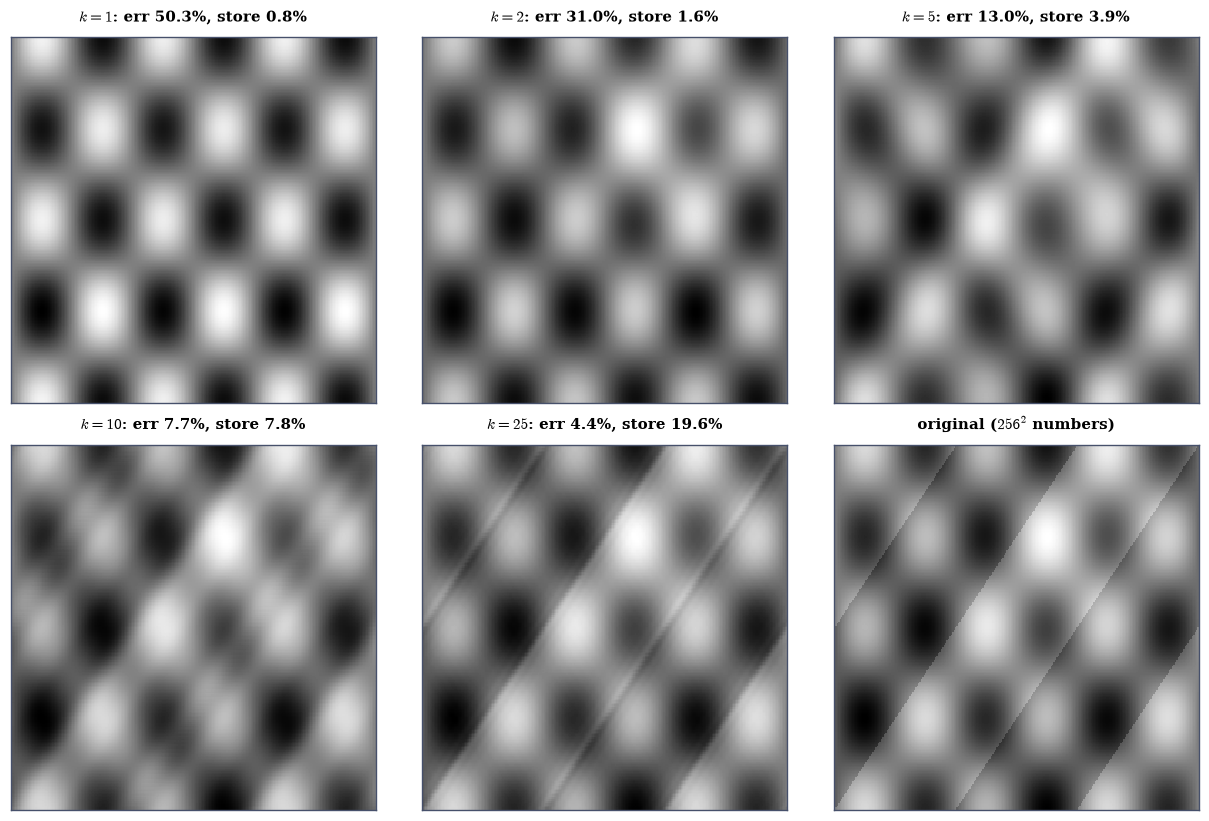

In [15]:
# (solution hidden on the public site)


### Validation 5

The $k = 25$ gate is the manifest's contract for this notebook, and the
planning check underneath it is the part with content: the error of every
candidate $k$ was priced from the spectrum before any reconstruction was
formed, which is what makes {eq}`eq-ey-theorem` an engineering tool rather
than a certificate issued after the fact.

In [16]:
validate.below(
    max(ey_img), 1e-10,
    "Eckart-Young holds on the image at every k tested (Eq. 2)",
)
validate.check(
    rel25 < 0.05 and store25 < 0.30,
    "k = 25 delivers under 5% error at under 30% storage, as contracted",
    f"{100*rel25:.2f}% error at {100*store25:.1f}% of mn: a {1/store25:.1f}x "
    "compression from the same theorem that lost on the 8x8 digit",
)
validate.check(
    20 <= k_plan <= 25,
    "and that k was priced from the spectrum alone, before any reconstruction",
    f"the tail energy first drops below 5% at k = {k_plan}: Eq. 2 turns "
    "compression into a planning problem",
)
validate.check(
    bool(np.all(np.diff([gallery[k][0] for k in panels]) < 0)),
    "the gallery's errors fall monotonically in k",
    f"errors {[f'{gallery[k][0]:.3f}' for k in panels]} at k = {panels}",
)

✓  Eckart-Young holds on the image at every k tested (Eq. 2)   [6.20714e-16 < 1e-10]
✓  k = 25 delivers under 5% error at under 30% storage, as contracted   [4.43% error at 19.6% of mn: a 5.1x compression from the same theorem that lost on the 8x8 digit]
✓  and that k was priced from the spectrum alone, before any reconstruction   [the tail energy first drops below 5% at k = 21: Eq. 2 turns compression into a planning problem]
✓  the gallery's errors fall monotonically in k   [errors ['0.503', '0.310', '0.130', '0.077', '0.044'] at k = [1, 2, 5, 10, 25]]


True

```{admonition} With your assistant
:class: tip
For a *symmetric* matrix the truncated SVD can be built from the
eigendecomposition instead — but only with care, because the singular values
of a symmetric $S$ are $|\lambda_i|$, so the truncation must keep the
eigenvalues **largest in magnitude**, negative ones included. Ask your
assistant to write `truncate_symmetric(S, k)` doing exactly that via
`np.linalg.eigh`. Then check it against the mathematics rather than against a
picture: on $S = (B + B^{\top})/2$ for a random $8\times8$ $B$, verify
(i) its output matches the SVD truncation `truncate(...)` to $10^{-12}$ for
every $k$, (ii) $\|S - S_k\|_2 = |\lambda|_{(k+1)}$ — the $(k+1)$-th largest
*magnitude* — to $10^{-12}$, and (iii) that keeping the $k$ *algebraically*
largest eigenvalues instead breaks both identities the moment a large
negative eigenvalue exists. The check is yours.
```

---
## Notebook summary

**The error is known before the approximation is formed.** On the $9\times7$
matrix with constructed spectrum $\sigma_i = 10^{-(i-1)/2}$, the measured
$\|A - A_k\|_2$ equalled $\sigma_{k+1}$ and $\|A - A_k\|_F$ equalled the tail
energy $\sqrt{\sum_{i>k}\sigma_i^2}$ to a relative $1.7\times10^{-14}$ at
**every** rank $k = 1,\dots,6$, with $\operatorname{rank}(A_k) = k$ exactly
and the rank-1 outer-product sum matching the block form to rounding.

**No challenger wins.** $10^4$ random rank-3 competitors — each given the best
approximation available in its own column space, so the contest was over
subspaces — produced zero violations of {eq}`eq-ey-theorem`, with the best of
them still $8.6\times$ worse in the 2-norm and $10.0\times$ worse in
Frobenius. The SVD's own subspace reproduced $A_3$ to rounding: the optimum is
attained, and nowhere else.

**Low-rank structure announces itself as a cliff.** The rank-2-plus-noise
matrix showed $\sigma_3/\sigma_1 = 0.0065$ with $99.98\%$ of the Frobenius
energy in two directions — and truncating there landed $7.5\times$ **closer
to the true signal than the data itself**, because what was discarded was
noise. `matrix_rank` returned 40 by default and 2 at any threshold inside the
cliff, both correctly: {eq}`eq-ey-numrank` is honest only with $\tau$ stated.

**Compression is a bookkeeping question with a break-even.** On the
$8\times8$ digit (exact rank 6), the last storage-saving rank $k = 3$ still
carried $20.7\%$ error while $k = 4$ cost more numbers than the raw pixels:
the theorem held to $10^{-13}$ and the compression *lost*, because
$mn/(m+n+1) = 3.8$. On the $256\times256$ image the same theorem delivered
$4.4\%$ error at $19.6\%$ storage at $k = 25$ — and that $k$ was priced from
the spectrum alone, the tail energy first dropping below $5\%$ at $k = 22$,
before any reconstruction was formed.

**Methods introduced.** `truncate` via broadcast `(U[:, :k] * s[:k]) @ Vt[:k]`,
the rank-1 accumulation, fair random challengers by projection onto random
subspaces, `la.low_rank_plus_noise` and the cliff diagnostic,
`np.linalg.matrix_rank` with an explicit `tol`, the storage count
$k(m+n+1)$, and tail-energy pricing of a compression before forming it.

## Outlook

- **The same truncation, centred, is PCA.** Subtract each column's mean first
  and the top singular directions become the directions of maximal variance;
  Eckart–Young then says PCA's reconstruction error is exactly the discarded
  variance. [§4.3](pca-covariance-whitening.ipynb) makes the dictionary
  precise.
- **When even one SVD is too expensive.** The $256\times256$ SVD was free; at
  $10^6\times10^6$ it is not, and the whole factorization is overkill when
  only $k = 25$ directions are wanted. Randomized methods get the leading
  subspace from a handful of matrix products with a probabilistic guarantee,
  and [§4.4](randomized-svd-sketching.ipynb) builds them.
- **Choosing $k$ when there is no cliff.** The pure-noise spectrum in
  Exercise 3 had no gap, and real spectra are often in between. Principled
  choices — optimal hard thresholds under a noise model, cross-validation —
  start from the Marchenko–Pastur law for what *pure noise* singular values
  look like, which [§4.3](pca-covariance-whitening.ipynb) meets in its
  covariance form.
- **Low-rank plus a budget.** {eq}`eq-ey-storage` priced storage; the same
  accounting with *parameters* instead of numbers is why low-rank adapters
  fine-tune large models at a fraction of the cost, and
  [§8.6](../08-learning/low-rank-lora-quantization.ipynb) runs on exactly the
  identity measured here.

```{bibliography}
:filter: docname in docnames
```

In [17]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>